In [16]:
import os
import numpy as np
import matplotlib.pyplot as plt
from utilities import get_git_repo_path, log_bin

# Setup
git_path = get_git_repo_path()
target_frequency = 150929  # MHz
ref_time = 463.7943 # LJ time in fs
ref_temp = 50.3219 # LJ temp in K

In [17]:
all_n = [5] # , 20, 80, 320, 1280]

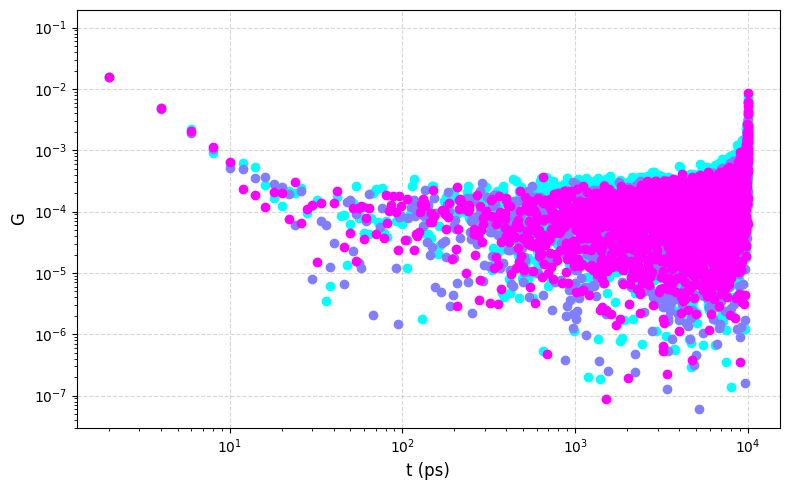

In [18]:
type = "full"

fig, ax = plt.subplots(figsize=(8, 5))

# Colormap and color assignment
cmap = plt.cm.cool
colors = cmap(np.linspace(0, 1, 3))

# Plot each R1 spectrum

n = all_n[0]

all_gij_0 = []
all_gij_1 = []
all_gij_2 = []

for repetition in range(10):

    result_file = f"nmr_{type}/result{n}-{repetition}.npy"
    data = np.load(result_file, allow_pickle=True).item()
    t = data["t"]
    gij_0 = data["C"][0]
    gij_1 = data["C"][1]
    gij_2 = data["C"][2]
    all_gij_0.append(gij_0)
    all_gij_1.append(gij_1)
    all_gij_2.append(gij_2)

mean_gij_0 = np.mean(all_gij_0, axis = 0)
mean_gij_1 = np.mean(all_gij_1, axis = 0)
mean_gij_2 = np.mean(all_gij_2, axis = 0)
std_gij_0 = np.std(all_gij_0, axis = 0)
std_gij_1 = np.std(all_gij_1, axis = 0)
std_gij_2 = np.std(all_gij_2, axis = 0)
    
ax.loglog(t, mean_gij_0, "o", label=f"n = {n:.1f}", color=colors[0])
ax.loglog(t, 6*mean_gij_1, "o", label=f"n = {n:.1f}", color=colors[1])
ax.loglog(t, 6/4*mean_gij_2, "o", label=f"n = {n:.1f}", color=colors[2])

# Axis labels and title
ax.set_xlabel("t (ps)", fontsize=12)
ax.set_ylabel("G", fontsize=12)
ax.grid(True, linestyle="--", alpha=0.5)

# plt.xlim([30, 5e4])
# plt.ylim([0.005, 3])

# Colorbar representing temperature gradient
# norm = plt.Normalize(vmin=0, vmax=1280)
# sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
# sm.set_array([])

# cbar = fig.colorbar(sm, ax=ax, label="number_i")

plt.tight_layout()
# plt.savefig(f"R1_{type}.png", dpi=300)
plt.show()

IndexError: index 1 is out of bounds for axis 0 with size 1

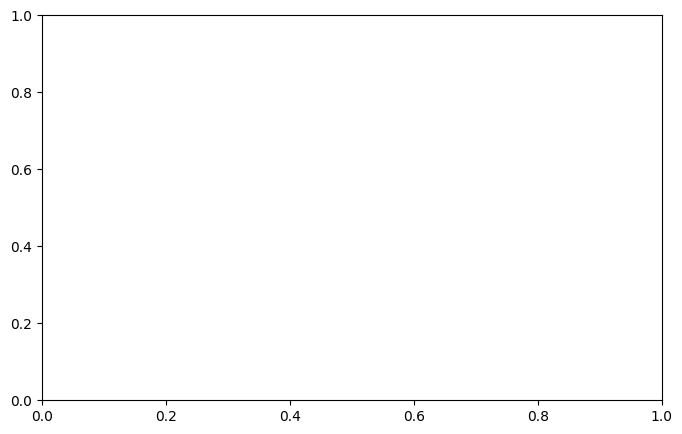

In [26]:
type = "inter"

fig, ax = plt.subplots(figsize=(8, 5))

# Colormap and color assignment
cmap = plt.cm.cool
colors = cmap(np.linspace(0, 1, 3))

# Plot each R1 spectrum

n = all_n[0]

all_gij_0 = []
all_gij_1 = []
all_gij_2 = []

for repetition in range(10):

    result_file = f"nmr_{type}/result{n}-{repetition}.npy"
    data = np.load(result_file, allow_pickle=True).item()
    t = data["t"]
    gij_0 = data["C"][0]
    gij_1 = data["C"][1]
    gij_2 = data["C"][2]
    all_gij_0.append(gij_0)
    all_gij_1.append(gij_1)
    all_gij_2.append(gij_2)

mean_gij_0 = np.mean(all_gij_0, axis = 0)
mean_gij_1 = np.mean(all_gij_1, axis = 0)
mean_gij_2 = np.mean(all_gij_2, axis = 0)
std_gij_0 = np.std(all_gij_0, axis = 0)
std_gij_1 = np.std(all_gij_1, axis = 0)
std_gij_2 = np.std(all_gij_2, axis = 0)
    
ax.loglog(t, mean_gij_0, "o", label=f"n = {n:.1f}", color=colors[0])
ax.loglog(t, 6*mean_gij_1, "o", label=f"n = {n:.1f}", color=colors[1])
ax.loglog(t, 6/4*mean_gij_2, "o", label=f"n = {n:.1f}", color=colors[2])

# Axis labels and title
ax.set_xlabel("t (ps)", fontsize=12)
ax.set_ylabel("G", fontsize=12)
ax.grid(True, linestyle="--", alpha=0.5)

# plt.xlim([30, 5e4])
# plt.ylim([0.005, 3])

# Colorbar representing temperature gradient
# norm = plt.Normalize(vmin=0, vmax=1280)
# sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
# sm.set_array([])

# cbar = fig.colorbar(sm, ax=ax, label="number_i")

plt.tight_layout()
# plt.savefig(f"R1_{type}.png", dpi=300)
plt.show()

In [29]:
from nmrdfrommd import compute_rij, cartesian_to_spherical, \
    spherical_harmonic_kernel, ALPHA_M

In [ ]:
import os
import numpy as np
import MDAnalysis as mda

from utilities import get_git_repo_path

git_path = get_git_repo_path()
data_dir = os.path.join(git_path, "data")
topology_file = os.path.join(data_dir, "equilibrate.data")
trajectory_file = os.path.join(data_dir, "production.xtc")

u = mda.Universe(topology_file, trajectory_file)
dt = u.trajectory.dt

target_group = u.select_atoms("type 2")
neighbor_group = u.select_atoms("type 2")

from nmrdfrommd import NMRD

nmr_intra_H2O = NMRD(
    u=u,
    atom_group=u.select_atoms("type 2"),
    type_analysis="intra_molecular",
    number_i=1)
results_nmr_intra_H2O = nmr_intra_H2O.run_analysis()

group_i = nmr_intra_H2O.group_i
group_j = nmr_intra_H2O.group_j

matrix_rij = []
matrix_Fval = []
all_r = []
all_theta = []
all_phi = []

for cpt, ts in enumerate(u.trajectory):

    position_i = group_i.atoms.positions
    position_j = group_j.atoms.positions
    box = ts.dimensions

    rij = compute_rij(position_i, position_j, box, True)

    matrix_rij.append(rij)

    r, theta, phi = cartesian_to_spherical(rij)

    all_r.append(r[0])
    all_theta.append(theta[0])
    all_phi.append(phi[0])

    F_val = spherical_harmonic_kernel(r, theta, phi, ALPHA_M, True)

    matrix_Fval.append(F_val[0][0])

matrix_rij = np.array(matrix_rij)
matrix_Fval = np.array(matrix_Fval)
all_r = np.array(all_r)
all_theta = np.array(all_theta)
all_phi = np.array(all_phi)

time = np.arange(u.trajectory.n_frames) * dt

np.savetxt("intra_r.dat", np.vstack([time, all_r]).T)
np.savetxt("intra_theta.dat", np.vstack([time, all_theta]).T)
np.savetxt("intra_phi.dat", np.vstack([time, all_phi]).T)
np.savetxt("intra_F.dat", np.vstack([time, matrix_Fval]).T)

In [84]:
nmr_inter_H2O = NMRD(
    u=u,
    atom_group=u.select_atoms("type 2"),
    type_analysis="inter_molecular",
    number_i=1)
results_nmr_inter_H2O = nmr_inter_H2O.run_analysis()

group_i = nmr_inter_H2O.group_i
group_j = nmr_inter_H2O.group_j

matrix_rij = []
matrix_Fval = []
all_r = []
all_theta = []
all_phi = []

id = 1

for cpt, ts in enumerate(u.trajectory):

    position_i = group_i.atoms.positions
    position_j = group_j.atoms.positions
    box = ts.dimensions

    rij = compute_rij(position_i, position_j, box, True)

    matrix_rij.append(rij)

    r, theta, phi = cartesian_to_spherical(rij)

    all_r.append(r[id])
    all_theta.append(theta[id])
    all_phi.append(phi[id])

    F_val = spherical_harmonic_kernel(r, theta, phi, ALPHA_M, True)

    matrix_Fval.append(F_val[0][id])

matrix_rij = np.array(matrix_rij)
matrix_Fval = np.array(matrix_Fval)

print(np.max(matrix_Fval))

all_r = np.array(all_r)
all_theta = np.array(all_theta)
all_phi = np.array(all_phi)

time = np.arange(u.trajectory.n_frames) * dt

np.savetxt("inter_r.dat", np.vstack([time, all_r]).T)
np.savetxt("inter_theta.dat", np.vstack([time, all_theta]).T)
np.savetxt("inter_phi.dat", np.vstack([time, all_phi]).T)
np.savetxt("inter_F.dat", np.vstack([time, matrix_Fval]).T)

0.26303515195790633
